## General Instructions
---

1. This lab must be completed **individually**.

2. You may use the following libraries:
   - seaborn  
   - matplotlib  
   - pandas  
   - numpy  
   - csv  
   - scikit
  
   However, you are **NOT** allowed to use the direct inbuilt classifier functions.

3. All code must be submitted in the form of a **single Jupyter notebook**.

4. Marks for each sub-section are mentioned in the respective questions.

5. You may use **Google Colab** to run the Jupyter notebook  
   (https://colab.research.google.com/).  
   References for loading data in Colab:
   - https://towardsdatascience.com/3-ways-to-load-csv-files-into-colab-7c14fcbdcb92  
   - https://www.marktechpost.com/2019/06/07/how-to-connect-google-colab-with-google-drive/  
   Alternatively, you may run the notebook locally using **Anaconda Jupyter Notebook**.

6. The lab must be submitted on **Google Classroom**.  
   Please make sure to run the cells before submitting so that the outputs are visible.

7. **Code readability is very important.**  
   - Modularize your code using functions and/or classes  
   - Use self-explanatory variable names  
   - Add comments to clearly describe your approach  
   - You may add additional code or text cells wherever necessary

8. You are expected to submit your **observations**, and not just an error-free implementation.

9. Students are expected to strictly follow the **honor code** of the class.

10. The deadline is **strict**. Assignments submitted after the deadline will not be considered for evaluation unless prior permission is obtained at least **4 days before** the submission deadline.

11. Marks will be awarded based on:
    - Quality of code
    - Use of innovative data structures
    - Scalability
    - Correctness
    - Completeness and clarity of reported observations

12. In case of any queries regarding **Lab 2**, please contact the TAs via email (details provided on Google Classroom).

13. Fix the random seed value to **42** to ensure reproducibility of results.

14. You may choose any appropriate learning rate of your choice for training the models.

# **Task 1: Experimental Analysis of Logistic Regression Variants**

## Dataset:

We will use the **Car Evaluation Dataset** from the UCI Machine Learning Repository:

https://archive.ics.uci.edu/ml/datasets/car+evaluation

The dataset contains **1,728 samples**, described using **six categorical attributes**:
- buying
- maint
- doors
- persons
- lug_boot
- safety

### Target Variable (Ordinal)

The original class labels are:
unacc < acc < good < vgood

For this assignment, convert them into **three ordered classes**:

Low    → unacc  
Medium → acc  
High   → good + vgood  

Thus, the final label space is:
y ∈ {1, 2, 3}  (Low < Medium < High)

---

## **Part 1(a): Data Preparation and Ordinal Structure Exploration [ 1+0.5+0.5 = 2 marks]**

1. Load the dataset and perform suitable preprocessing:
   - Encode categorical features (One-hot encoding)
   <!-- - Normalize features if required -->
2. Show the distribution of samples across the three ordinal classes.
<!-- 3. Visualize at least two feature–feature plots colored by class label. -->

3. **Observations to report:**
- Class imbalance (if any)
- Degree of overlap between adjacent ordinal classes (Low–Medium, Medium–High)
  
  For each feature:

	•	Make one bar plot per class

	•	Visually compare Low vs Medium, Medium vs High

  If bars look similar → overlap

  If bars look different → separation

## **Part 1(b): Linear Classifier [ 2+1+1 = 4 marks]**
Implement the Linear Classifier and visualize the classified samples based on the buying and maint features. Mark the misclassified samples with different color. Report your observations.

## **Part 2: One-vs-Rest Logistic Regression [2+1+0.5+0.5+1 = 5 marks]**

Since logistic regression is inherently binary, multi-class problems are often handled using **One-vs-Rest (OvR)**.

In OvR, one binary classifier is trained per class:

P(y = k | x) = σ(w_kᵀ x + b_k)

Prediction rule:

ŷ = argmax_k P(y = k | x)

One-vs-Rest trains one yes/no classifier per class and predicts the class whose classifier is most confident.

### Tasks:
1. Implement OvR logistic regression.
2. Train using an **80–20 train–test split**.
3. Report:
   - Training accuracy
   - Testing accuracy
4. Plot the **confusion matrix**.

5. **Observations to report:**
- Which class is most frequently misclassified?
- Are extreme errors (Low ↔ High) common?


## **Part 3: Effect of Regularization (L1 vs L2) [4+2+1+2 = 10 marks]**

Regularization is used to control overfitting and feature dependence.

### Ridge (L2) Logistic Regression:
Loss = − Σ log P(y_i | x_i) + λ ||w||₂²

### Lasso (L1) Logistic Regression:
Loss = − Σ log P(y_i | x_i) + λ ||w||₁

### Tasks:
<!-- 1. Extend either OvR or multinomial logistic regression with: -->
1. Extend OvR logistic regression with:
   - L2 regularization
   - L1 regularization
2. Train both models with identical settings.
3. Report:
   - Training accuracy
   - Testing accuracy
   <!-- - Number of non-zero weights -->

4. **Observations to report:**
- Effect of L1 vs L2 on sparsity
<!-- - Stability of predictions across classes -->
- Impact on generalization performance


## **Part 4: Ordinal Logistic Regression [7+1+1+3 = 12 marks]**

Ordinal logistic regression explicitly models the ordering of class labels.

For a 3-class problem, the model learns:
- A single weight vector w
- Two ordered thresholds θ₁ < θ₂

### Cumulative probability model:

P(y ≤ 1 | x) = σ(θ₁ − wᵀ x)

P(y ≤ 2 | x) = σ(θ₂ − wᵀ x)

Ordinal logistic regression is trained by jointly learning a shared weight vector and ordered thresholds. The weight vector is typically initialized to zeros (or small random values), and the thresholds are initialized as ordered constants (for example, θ₁ = 0 and θ₂ = 1 for a three-class problem). The weights map input features to a single score, while the thresholds split this score into ordered class regions. Both weights and thresholds are updated using gradient descent by minimizing the negative log-likelihood. During training, gradients indicate how to adjust the weights and thresholds to increase the probability of the true class, while ensuring that the ordering constraint θ₁ < θ₂ is preserved.

### Class probabilities:

P(y = 1) = P(y ≤ 1)

P(y = 2) = P(y ≤ 2) − P(y ≤ 1)

P(y = 3) = 1 − P(y ≤ 2)

### Tasks:
1. Implement ordinal logistic regression using the cumulative logit formulation.
2. Train using the same data split as previous parts.
3. Evaluate using:
   - Accuracy
   - Mean Absolute Error (MAE)

4. **Observations to report:**
- Are extreme errors (Low ↔ High) reduced?
<!-- - Compare MAE with multinomial logistic regression. -->
- Comment on ordinal consistency of predictions. Are the model’s predictions aligned with the natural ordering of the classes, or does it behave as if the classes were unrelated categories?


## **Part 5: Analysis [1+1+1 = 3 marks]**

Summarize and compare all models (variants of logistic regression and linear model) with respect to:
- Accuracy
- Ordinal error behavior
- Suitability for ordered labels

In [1]:
pip install turbo-ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.3/280.3 kB 5.9 MB/s eta 0:00:00


In [2]:
pip install ucimlrepo numpy pandas matplotlib seaborn scikit-learn

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error

In [4]:
# fetch dataset
#car_evl car evaluation
car_evl = fetch_ucirepo(id=19)

# feature & target
X_raw = car_evl.data.features
y_raw = car_evl.data.targets

In [5]:
print(car_evl.metadata)
print(car_evl.variables)

{'uci_id': 19, 'name': 'Car Evaluation', 'repository_url': 'https://archive.ics.uci.edu/dataset/19/car+evaluation', 'data_url': 'https://archive.ics.uci.edu/static/public/19/data.csv', 'abstract': 'Derived from simple hierarchical decision model, this database may be useful for testing constructive induction and structure discovery methods.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1728, 'num_features': 6, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1988, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5JP48', 'creators': ['Marko Bohanec'], 'intro_paper': {'ID': 249, 'type': 'NATIVE', 'title': 'Knowledge acquisition and explanation for multi-attribute decision making', 'authors': 'M. Bohanec, V. Rajkovič', 'venue': '8th Intl Workshop on Expert Systems and their Applications, 

In [6]:

#unacc < acc < good < vgood
#Low-1
#Medium -2
#High- 3

label_map = {
    "unacc": 1,
    "acc": 2,
    "good": 3,
    "vgood": 3
}

y = y_raw.iloc[:, 0].map(label_map).values

In [7]:
encoder = OneHotEncoder(sparse_output=False)
X = encoder.fit_transform(X_raw)

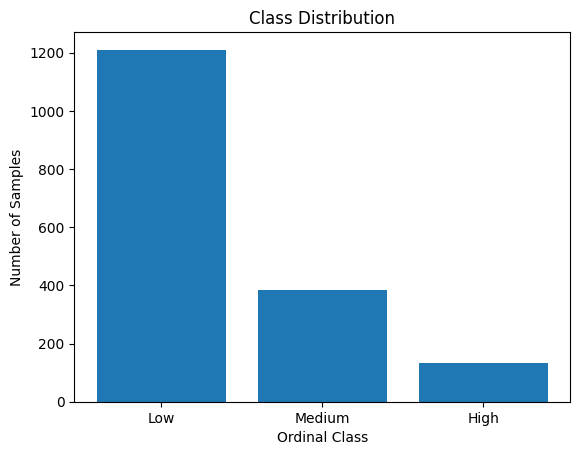

In [8]:
#cls_cnt = class counts

cls_cnt = pd.Series(y).value_counts().sort_index()

plt.bar(["Low", "Medium", "High"], cls_cnt)
plt.xlabel("Ordinal Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")
plt.show()

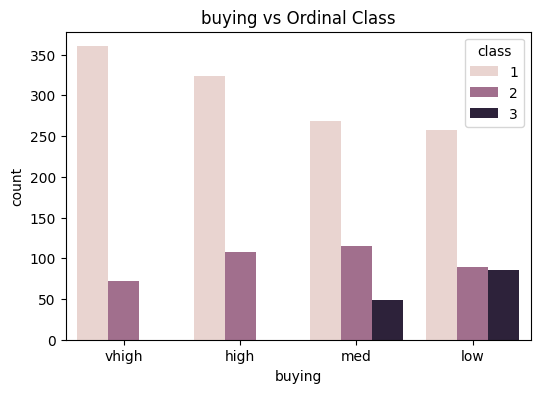

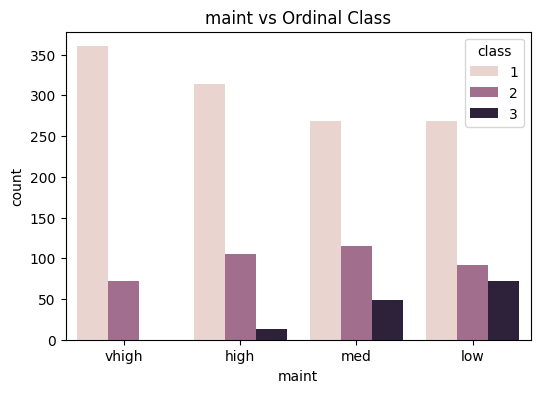

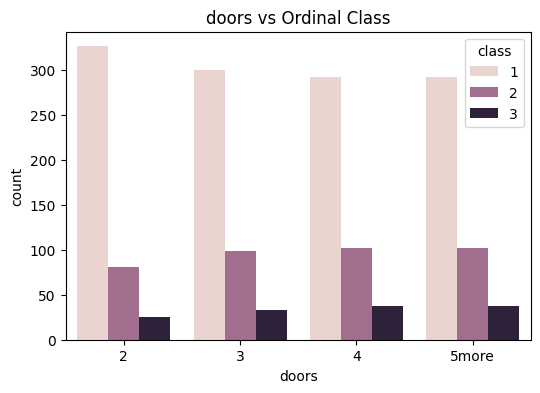

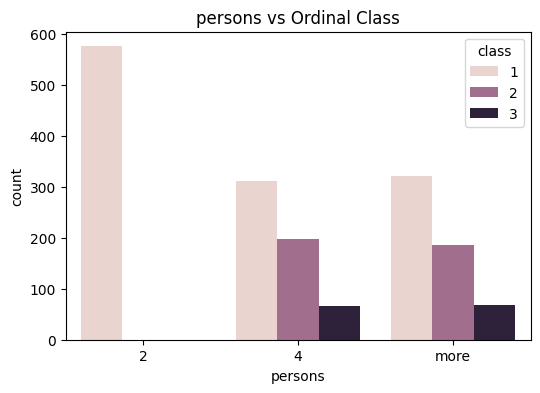

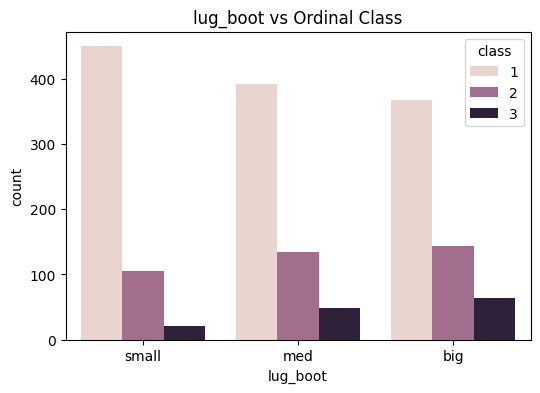

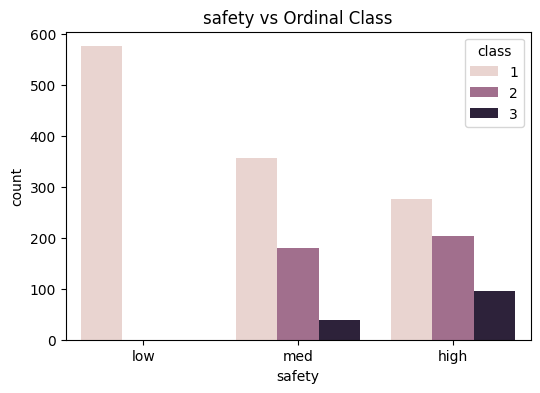

In [9]:
#d_vis = data visuals or visulization
d_vis = X_raw.copy()
d_vis["class"] = y

for col in X_raw.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="class", data=d_vis)
    plt.title(f"{col} vs Ordinal Class")
    plt.show()

In [10]:
#part 1b starts

In [11]:
#lin_clf = linear classification
lin_clf = LogisticRegression(
    penalty=None,
    multi_class="ovr",
    solver="lbfgs",
    max_iter=1000
)

lin_clf.fit(X, y)
y_pred = lin_clf.predict(X)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


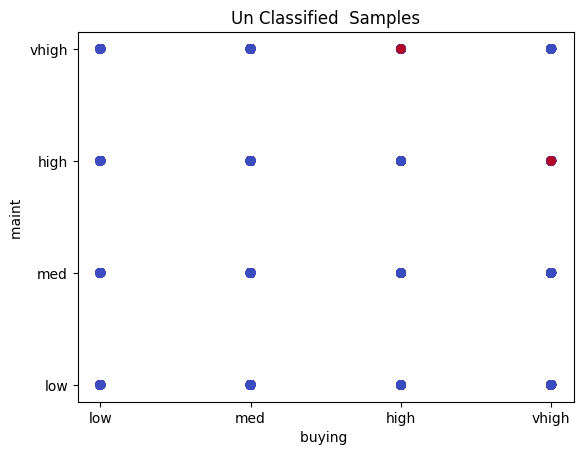

In [12]:
#cols_two = two type of variants only in the coloumns defined
cols_two = ["buying", "maint"]


#b_map = buying map
#m_map = maint map
b_map = {'low': 0, 'med': 1, 'high': 2, 'vhigh': 3}
m_map = {'low': 0, 'med': 1, 'high': 2, 'vhigh': 3}

#xpb = PLot x for buying
#xpm = Plot x for maint
xpb = X_raw['buying'].map(b_map)
xpm = X_raw['maint'].map(m_map)

plt.scatter(
    xpb,
    xpm,
    c=(y!=y_pred),
    cmap="coolwarm"
)

plt.xlabel("buying ")
plt.ylabel("maint ")
plt.title("Un Classified  Samples")
plt.xticks(list(b_map.values()),list(b_map.keys()))
plt.yticks(list(m_map.values()), list(m_map.keys()))
plt.show()

In [13]:
X_train,X_test,y_train ,y_test= train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
ovr_clf = LogisticRegression(
    multi_class="ovr",
    solver="lbfgs",
    max_iter=1000
)

ovr_clf.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='ovr')

In [15]:
print("Train Accuracy:",
      accuracy_score(y_train, ovr_clf.predict(X_train)))

print("Test Accuracy:",
      accuracy_score(y_test, ovr_clf.predict(X_test)))

Train Accuracy: 0.914616497829233
Test Accuracy: 0.8988439306358381


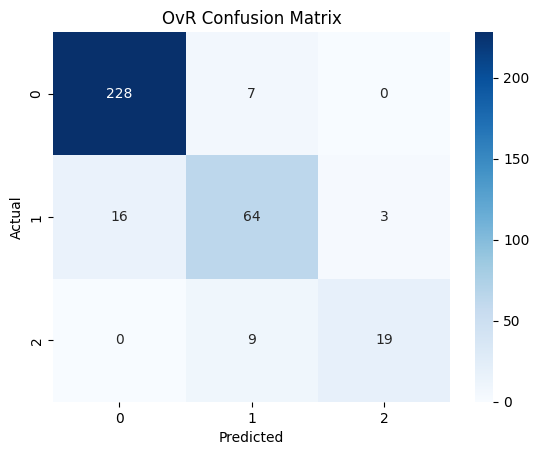

In [16]:
cm = confusion_matrix(y_test, ovr_clf.predict(X_test))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("OvR Confusion Matrix")
plt.show()

In [17]:
l2_clf = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    multi_class="ovr",
    max_iter=1000
)

l2_clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='ovr')

In [18]:
l1_clf = LogisticRegression(
    penalty="l1",
    C=1.0,
    solver="liblinear",
    multi_class="ovr",
    max_iter=1000
)

l1_clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='ovr', penalty='l1',
                   solver='liblinear')

In [19]:
print("L2 Test Accuracy:",
      accuracy_score(y_test, l2_clf.predict(X_test)))

print("L1 Test Accuracy:",
      accuracy_score(y_test, l1_clf.predict(X_test)))

print("L1 Non-zero weights:",
      np.sum(l1_clf.coef_ != 0))

print("L2 Non-zero weights:",
      np.sum(l2_clf.coef_ != 0))

L2 Test Accuracy: 0.8988439306358381
L1 Test Accuracy: 0.9248554913294798
L1 Non-zero weights: 50
L2 Non-zero weights: 63


In [20]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [21]:
def train_ordinal(X, y, lr=0.01, epochs=800):
    n, d = X.shape

    w = np.zeros(d)
    t1, t2 = 0.0, 1.0

    for _ in range(epochs):
        z = X@w
        p1 = sigmoid(t1 - z)
        p2 = sigmoid(t2 - z)

        gw = np.zeros(d)
        gt1, gt2 = 0.0, 0.0

        for i in range(n):
            if y[i] == 1:
                gw += (1- p1[i])* X[i]
                gt1 -= (1 -p1[i])
            elif y[i] == 2:
                gw += (p1[i]- p2[i]) * X[i]
                gt1 += p1[i]
                gt2 -= (1 -p2[i])
            else:
                gw += p2[i] *X[i]
                gt2 += p2[i]

        w -= lr*gw/n
        t1 -= lr*gt1/n
        t2 -= lr*gt2/n

    return w, t1, t2

In [22]:
def predict_ordinal(X, w, t1, t2):
    z = X @ w
    y_hat = []

    for v in z:
        if v<t1:
            y_hat.append(1)
        elif v <t2:
            y_hat.append(2)
        else:
            y_hat.append(3)

    return np.array(y_hat)

In [23]:
w, t1, t2 = train_ordinal(X_train, y_train)

y_ord = predict_ordinal(X_test, w, t1, t2)

print("Ordinal Accuracy:",
      accuracy_score(y_test, y_ord))

print("Ordinal MAE:",
      mean_absolute_error(y_test, y_ord))

Ordinal Accuracy: 0.6791907514450867
Ordinal MAE: 0.40173410404624277


# Task 2: Decision Trees Classification (35 Marks)

The Iris dataset consists of 150 instances belonging to three flower species, each represented by four numerical attributes. The dataset can be directly accessed using sklearn.datasets, making it suitable for controlled experimentation. In this assignment, you will examine how splitting criteria, model complexity, and data partitioning strategies affect the performance and stability of a Decision Tree classifier.

**Note:** You are NOT allowed to use the inbuilt Decision Tree implementation from sklearn. The classifier must be implemented from scratch.

### 1. **Dataset Understanding (2 Marks)**
    
 Load the Iris dataset using appropriate tools from sklearn. Report the dimensionality of the dataset, the feature names, and the class labels. Using a random seed value of 42, split the dataset into training and test subsets with an 80:20 ratio. Display a small representative subset of both the splits.

### 2.  **Training the decision tree (7+3+2+2 = 14 Marks)**
    
  a.) Train a Decision Tree classifier with **Entropy** as the splitting criterion.

  b.) Visualize the learned tree, clearly indicating the feature splits and predicted class labels.

  c.) Report the depth of the tree and the number of leaf nodes, and briefly comment on the interpretability of the resulting model.

  d.) Evaluate the trained classifier using accuracy, precision, recall, and F1-score, and present the corresponding confusion matrix. Analyze and comment on the class-wise performance.

### 3. **Entropy vs Gini Index (4+2 = 6 Marks)**
    
   Next, investigate the effect of the splitting criterion.
   
   a.) Train another Decision Tree model using the **Gini index**, while keeping all other parameters unchanged.
   
   b.) Compare the resulting trees in terms of structural complexity and classification performance, and discuss any notable differences.

### 4. **Role of Max Depth (4+1 = 5 Marks)**

  a.) To study the role of model complexity, vary the maximum depth of the tree over a reasonable range (You can use three different depth values) and analyze its impact on training and test performance.

  b.) Identify a depth that offers a suitable trade-off between underfitting and overfitting, and justify your choice based on the observed results.

<!-- ### 5. **Role of Data Partitioning (4+1 = 5 Marks)**

  a.) Finally, assess the robustness of the Decision Tree classifier by training three different random seed values {42, 3, 30} for the train–test split. (Use any splitting criterion and keep other parameters constant)
  
  b.) Compare the evaluation metrics obtained across these runs and comment on the stability of the model with respect to data partitioning. -->


### 5. **Random Forest Classifier (5+2+1 = 8 Marks)**

Decision Trees are known to be high-variance models and can be sensitive to the specific training data. Ensemble methods such as Random Forests address this limitation through bootstrap aggregation (bagging) and random feature selection.

a.)Train a Random Forest classifier on the Iris dataset using a fixed number of trees (Use num_trees = 5). Ensure that each tree is trained on a bootstrap sample of the training data, while keeping the train–test split and evaluation protocol identical to the earlier experiments.

b.) Compare the performance of the Random Forest classifier with that of a single Decision Tree in terms of accuracy, precision, recall, F1-score, and confusion matrix. Comment on any improvements or changes observed.

c.) Using the obtained results, explain how bagging helps reduce variance and improves model stability. In your discussion, relate the ensemble behavior of Random Forests to the sensitivity of individual Decision Trees observed in earlier sections of the assignment.
  


In [24]:
import numpy as np
import pandas as pd

import sklearn.datasets as datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [25]:
iris = datasets.load_iris()
x = iris.data
y = iris.target
fn = iris.feature_names
cn = iris.target_names

In [26]:
print("Shape of dataset",x.shape)
print("list of features",fn)
print("Class names",cn)

Shape of dataset (150, 4)
list of features ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class names ['setosa' 'versicolor' 'virginica']


In [27]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [28]:
print("Training Samples:\n",x_train[:5])
print("Training Labls:\n",y_train[:5])
print("Test Samples:\n",x_test[:5])
print("Test Labels:\n",y_test[:5])

Training Samples:
 [[4.6 3.6 1.  0.2]
 [5.7 4.4 1.5 0.4]
 [6.7 3.1 4.4 1.4]
 [4.8 3.4 1.6 0.2]
 [4.4 3.2 1.3 0.2]]
Training Labls:
 [0 0 1 0 0]
Test Samples:
 [[6.1 2.8 4.7 1.2]
 [5.7 3.8 1.7 0.3]
 [7.7 2.6 6.9 2.3]
 [6.  2.9 4.5 1.5]
 [6.8 2.8 4.8 1.4]]
Test Labels:
 [1 0 2 1 1]


In [29]:
def entropy(y):
  classes , counts = np.unique(y,return_counts=True)
  p = counts/counts.sum()
  ent = 0
  for p_val in p:
    if p_val > 0:
      ent -= p_val*np.log2(p_val)
  return ent

In [30]:
def infogain(y,yl,yr):
  wl = len(yl)/len(y)
  wr = len(yr)/len(y)
  return entropy(y)-(wl*entropy(yl)+wr*entropy(yr))

In [31]:
#Node for Decision tree classifier
class Node:
  def __init__(self,feature=None,threshold = None , left = None, right = None , value = None):
    self.feature = feature
    self.threshold = threshold
    self.left = left
    self.right = right
    self.value = value

In [32]:
def gini(y):
  classes , counts = np.unique(y,return_counts=True)
  p = counts/counts.sum()
  return 1-np.sum(p**2)
def ginigain(y,yl,yr):
  wl = len(yl)/len(y)
  wr = len(yr)/len(y)
  return gini(y)-(wl*gini(yl)+wr*gini(yr))

class DecisionTree:
  def __init__(self,maxd = None,criterion = "entropy"):
    self.maxd = maxd
    self.criterion = criterion
    self.root = None
    #maxd = max depth
    # The line causing the error is now fixed by defining ginigain earlier in this cell.

  #split finderr
  def best_split(self,x,y):
    #bg = best gain
    #sx = split idx , st = split threshold
    bg = -1
    sx , st = None , None
    for feature in range(x.shape[1]):
      thresholds = np.unique(x[:,feature])
      for t in thresholds:
        lx = x[:,feature]<=t
        rx = x[:,feature]>t

        if len(y[lx])==0 or len(y[rx])==0:
          continue
        if self.criterion == "entropy":
          gain = infogain(y,y[lx],y[rx])
        else:
          gain = ginigain(y,y[lx],y[rx])
        if gain >bg:
          bg = gain
          sx = feature
          st = t
    return sx,st

  def buildtree(self,x,y,d=0):
    if len(np.unique(y))==1:
      return Node(value=y[0])
    if self.maxd is not None and d>=self.maxd:
      return Node(value=np.bincount(y).argmax())
    feat , th=self.best_split(x,y)
    if feat is None:
      return Node(value=np.bincount(y).argmax())
    lx = x[:,feat]<=th
    rx = x[:,feat]>th
    left = self.buildtree(x[lx],y[lx],d+1)
    right = self.buildtree(x[rx],y[rx],d+1)

    return Node(feat,th,left,right)

  def fit(self,x,y):
    self.root = self.buildtree(x,y)

  def p_one(self,x,node):
    if node.value is not None:
      return node.value
    if x[node.feature] <= node.threshold:
      return self.p_one(x,node.left)
    else:
      return self.p_one(x,node.right)
  def predict(self,x):
    return np.array([self.p_one(x_val,self.root) for x_val in x])

In [33]:
tree_entropy = DecisionTree()
tree_entropy.fit(x_train,y_train)
y_pred = tree_entropy.predict(x_test)

In [34]:
print("Accuracy:\n",accuracy_score(y_test,y_pred))
print("Precision:\n",precision_score(y_test,y_pred,average="macro"))
print("Recall:\n",recall_score(y_test,y_pred,average="macro"))
print("F1 Score:\n",f1_score(y_test,y_pred,average="macro"))
print("confusion matrix:\n",confusion_matrix(y_test,y_pred))

Accuracy:
 1.0
Precision:
 1.0
Recall:
 1.0
F1 Score:
 1.0
confusion matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [35]:
def gini(y):
  classes , counts = np.unique(y,return_counts=True)
  p = counts/counts.sum()
  return 1-np.sum(p**2)
def ginigain(y,yl,yr):
  wl = len(yl)/len(y)
  wr = len(yr)/len(y)
  return gini(y)-(wl*gini(yl)+wr*gini(yr))

In [36]:
tg = DecisionTree(criterion= "gini")
tg.fit(x_train,y_train)
ypg = tg.predict(x_test)

In [37]:
print("Acuracy of Entropy:\n",accuracy_score(y_test,y_pred))
print("Gini Accuray:\n",accuracy_score(y_test,ypg))

Acuracy of Entropy:
 1.0
Gini Accuray:
 1.0


In [38]:
depths = [1.3,5]
for d in depths:
  tree = DecisionTree(maxd =d)
  tree.fit(x_train,y_train)
  taacc = accuracy_score(y_train,tree.predict(x_train))
  teacc = accuracy_score(y_test,tree.predict(x_test))
  print("Depth:\n",d)
  print("Trauin Acc:\n",taacc)
  print("Test Acc:\n",teacc)
  print()


Depth:
 1.3
Trauin Acc:
 0.95
Test Acc:
 0.9666666666666667

Depth:
 5
Trauin Acc:
 0.9916666666666667
Test Acc:
 1.0



In [39]:
class RandomForest:
  def __init__(self,numt=5,maxd=None):
    self.numt=numt
    self.maxd = maxd
    self.trees=[]

  def fit(self,x,y):
    self.trees=[]
    for _ in range(self.numt):
      idx = np.random.choice(len(x),len(x),replace=True)
      xs = x[idx]
      ys =y[idx]

      tree=DecisionTree(maxd=self.maxd)
      tree.fit(xs,ys)
      self.trees.append(tree)

  def predict(self,x):
    treep = np.array([tree.predict(x) for tree in self.trees])
    fp = []

    for i in range(len(x)):
      vals,counts = np.unique(treep[:,i],return_counts=True)
      fp.append(vals[np.argmax(counts)])

    return np.array(fp)

In [40]:
rf = RandomForest(numt=5,maxd=3)
rf.fit(x_train,y_train)
rfp = rf.predict(x_test)

In [41]:
print("Accuracy for random forst:\n",accuracy_score(y_test,rfp))
print("Confusion Matrxi for random forst:\n",confusion_matrix(y_test,rfp))

Accuracy for random forst:
 1.0
Confusion Matrxi for random forst:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


# Task 3 : Support Vector Machine (30 Marks)

Use the same **Iris dataset** with an **80:20 train–test split** (random seed = 42) for this task. It can be observed that some class pairs in the dataset are not perfectly linearly separable, particularly due to overlap between certain classes. Support Vector Machines (SVMs) address this issue by maximizing the margin while allowing controlled misclassification using a soft-margin formulation.

[One-vs-One (OVO)](https://machinelearningmastery.com/one-vs-rest-and-one-vs-one-for-multi-class-classification/) involves creating a binary classifier for every possible pair of classes. For each pair of classes, a binary SVM classifier is trained using only the data points belonging to the two classes being compared. For example, with three classes (A, B, C), classifiers are trained for (A vs B), (A vs C), and (B vs C).


### 1. **OVO Linear SVM Implementation and Hyperparameter Tuning (5 + 3 = 8 Marks)**
a) Implement a **One-vs-One (OVO) Linear SVM** classifier.

b) Perform hyperparameter tuning to identify the optimal penalty parameter **C** using a suitable range of values.

### 2. **Decision Boundary Visualization (4 Marks)**
Using any two features from the dataset (for example, petal length and petal width), plot the decision boundary corresponding to the optimal value of **C**.

### 3. **Analysis of Parameter C in Linear SVM (4 + 3 = 7 Marks)**
a) For different values of **C**, plot the **number of support vectors** and **number of violated points (misclassified points)** on the Y-axis against **C** on the X-axis. Violated points are defined as data points that violate the SVM margin constraint (i.e., points lying inside the margin or misclassified).


b) Discuss how varying **C** affects the **margin width, model complexity and generalization behavior**.

### 4. **Analysis of Kernel SVM (3 + 3 = 6 Marks)**
Linear decision boundaries may not be sufficient when the data exhibits complex structures. [Kernels](https://www.geeksforgeeks.org/machine-learning/major-kernel-functions-in-support-vector-machine-svm/) help by implicitly mapping the original feature space into a higher-dimensional space where the data might be more easily separable.

a) Train non-linear SVM classifiers using **Polynomial kernel** (degree = 2) and **Radial Basis Function (RBF) kernel**. Compare the classifiers in terms of decision boundary smoothness, and number of support vectors.

b) For appropriate values of **C** (Penalty Parameter) and **γ** (Kernel Parameter), do either of the kernels show signs of overfitting? Justify your answer using visualizations and performance metrics.

### 5. **Evaluation Metrics (3 + 2 = 5 Marks)**
a) Evaluate the best-performing SVM model using **Precision, Recall and F1-score**.

b) Report and briefly interpret the results.

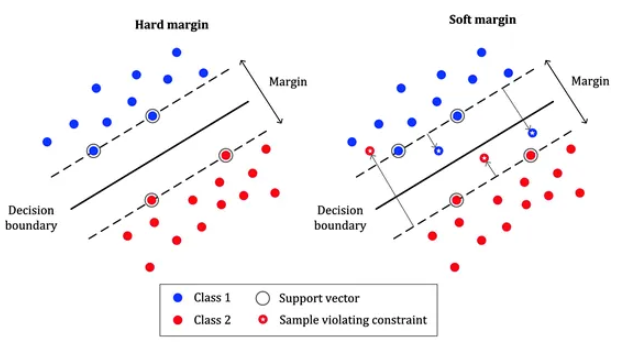



In [42]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [43]:
iris = load_iris()
x = iris.data
y = iris.target

fn = iris.feature_names
cn = iris.target_names

In [44]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [45]:
def trainovo(x,y,c):
  models = {}
  cses = np.unique(y)

#cses = classes
  for i in range(len(cses)):
    for j in range(i+1,len(cses)):
      c1,c2 = cses[i],cses[j]
      idx = (y==c1) | (y==c2)
      xp = x[idx]
      yp =y[idx]

      yp = np.where(yp==c1,-1,1)
      clf = SVC(kernel='linear',C=c)
      clf.fit(xp,yp)
      models[(c1,c2)] = clf
  return models

In [46]:
def predictovo(models,x):
  votes =np.zeros((x.shape[0],3))
  for(c1,c2) ,clf in models.items():
    preds = clf.predict(x)

    for i,p in enumerate(preds):
      if p == -1:
        votes[i,c1] += 1
      else:
        votes[i,c2] += 1
  return np.argmax(votes,axis =1)

In [47]:
cv = [0.01,0.1,1,10,100]
al = []
for c in cv:
  models = trainovo(x_train,y_train,c)
  y_pred = predictovo(models,x_test)
  acc = accuracy_score(y_test,y_pred)
  al.append(acc)

  print("c=",c,"Tes Accuracy= ",acc)

c= 0.01 Tes Accuracy=  0.9666666666666667
c= 0.1 Tes Accuracy=  1.0
c= 1 Tes Accuracy=  1.0
c= 10 Tes Accuracy=  0.9666666666666667
c= 100 Tes Accuracy=  1.0


In [48]:
best_c = cv[np.argmax(al)]
print("Best C:",best_c)

Best C: 0.1


In [49]:
xv = x_train[:,2:4]
yv = y_train
#xv = x visualization
#same for y

In [50]:
svm_vis = SVC(kernel="linear",C=best_c)
svm_vis.fit(xv,yv)

SVC(C=0.1, kernel='linear')

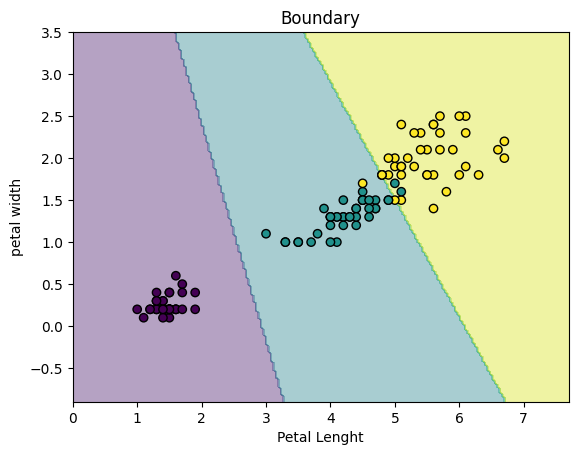

In [51]:
xm , xma = xv[:,0].min()-1,xv[:,0].max()+1
ym , yma = xv[:,1].min()-1,xv[:,1].max()+1

xx,yy = np.meshgrid(
    np.linspace(xm,xma,200),
    np.linspace(ym,yma,200)
)

z= svm_vis.predict(np.c_[xx.ravel(),yy.ravel()])
z = z.reshape(xx.shape)

plt.contourf(xx,yy,z,alpha=0.4)
plt.scatter(xv[:,0],xv[:,1],c=yv,edgecolors="k")

plt.xlabel("Petal Lenght")
plt.ylabel("petal width")
plt.title("Boundary")
plt.show()

In [52]:
svc =[]
v=[]

for c in cv:
  clf = SVC(kernel="linear",C=c)
  clf.fit(x_train,y_train)
  svc.append(len(clf.support_))
  y_pred=clf.predict(x_train)
  v.append(np.sum(y_pred!=y_train))

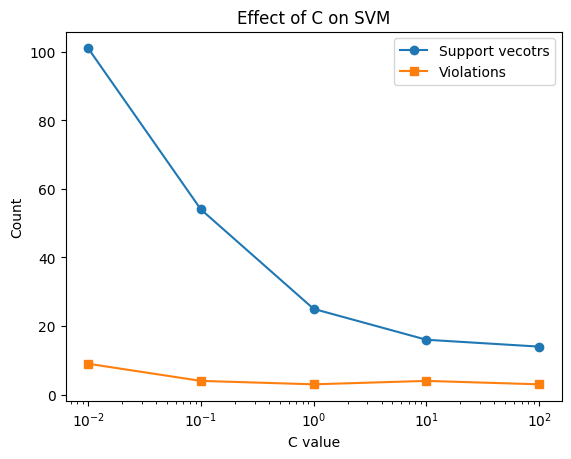

In [53]:
plt.plot(cv,svc,marker='o',label="Support vecotrs")
plt.plot(cv,v,marker='s',label="Violations")
plt.xscale("log")
plt.xlabel("C value")
plt.ylabel("Count")
plt.legend()
plt.title("Effect of C on SVM")
plt.show()

In [54]:
svm_poly = SVC(kernel="poly", degree=2, C=1)
svm_poly.fit(x_train, y_train)

SVC(C=1, degree=2, kernel='poly')

In [55]:
svm_rbf = SVC(kernel="rbf", C=10, gamma=0.5)
svm_rbf.fit(x_train, y_train)

SVC(C=10, gamma=0.5)

In [56]:
print("Linear SVs:", len(svm_vis.support_))
print("Poly SVs:", len(svm_poly.support_))
print("RBF SVs:", len(svm_rbf.support_))

Linear SVs: 56
Poly SVs: 29
RBF SVs: 31


In [57]:
bestm = svm_rbf
y_pred = bestm.predict(x_test)

In [58]:
print("precision: ",precision_score(y_test,y_pred,average="macro"))
print("recall score: ",recall_score(y_test,y_pred,average="macro"))
print("f1 score: ",f1_score(y_test,y_pred,average="macro"))

precision:  1.0
recall score:  1.0
f1 score:  1.0
